In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Versiyonu:", tf.__version__)

TensorFlow Versiyonu: 2.20.0-dev0+selfbuilt


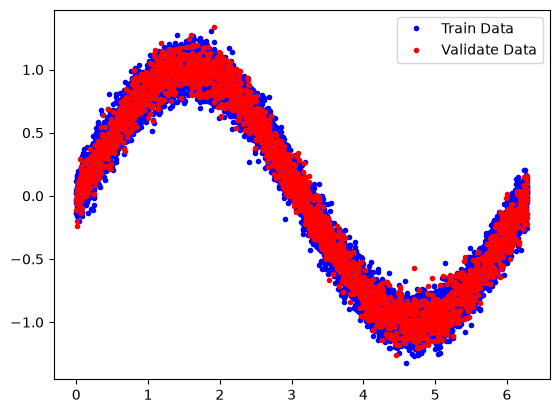

In [2]:
# 1. Addım: Təmiz bir sinus dalğası datası yaradaq
nsamples = 15000                                          # Ümumi nümunə sayı (5000 ədəd)
x_values = np.random.uniform(low=0, high=2*math.pi, size=nsamples).astype(np.float32)  
# 0 ilə 2π arasında təsadüfi x dəyərləri yaradırıq (float32 formatında)
np.random.shuffle(x_values)                              # x dəyərlərini qarışdırırıq (təsadüfiliyi artırmaq üçün)
y_values = np.sin(x_values).astype(np.float32)           # x dəyərlərinin sinusunu hesablayırıq (həqiqi cavab)

# 2. Addım: Real dünya datasına bənzəməsi üçün yüngül səs-küy (noise) əlavə edirik
noise = np.random.normal(scale=0.1, size=nsamples).astype(np.float32)  
# Orta qiyməti 0, standart sapması 0.1 olan normal paylanmadan səs-küy yaradırıq
y_values += noise                                        # Səs-küyü y dəyərlərinə əlavə edirik

# 3. Addım: Datani Train (%60), Validation (%20) və Test (%20) hissələrinə bölürük
TRAIN_SPLIT = int(0.80 * nsamples)                        # Təlim (train) üçün 60%
TEST_SPLIT = int(0.2 * nsamples) + TRAIN_SPLIT           # Test üçün növbəti 20% (qalan 20% validation olacaq)

x_train, x_validate, x_test = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])  
# x datalarını 3 hissəyə bölürük
y_train, y_validate, y_test = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])  
# y datalarını da eyni şəkildə bölürük

# Datani vizuallaşdıraq
plt.plot(x_train, y_train, 'b.', label="Train Data")     # Təlim datasını mavi nöqtələrlə göstər
plt.plot(x_validate, y_validate, 'r.', label="Validate Data")  # Validation datasını qırmızı nöqtələrlə göstər
plt.legend()                                             # Qrafikdə izahı (legend) göstər
plt.show()                                               # Qrafiki ekrana çıxar

In [3]:
# Sadə bir neyron şəbəkəsi modeli yaradırıq (Sequential - ardıcıl qatlar)
model = tf.keras.Sequential([
    # 1-ci gizli qat: 32 neyron, ReLU aktivasiya funksiyası
    # Giriş forması (1,) çünki hər nümunə tək bir rəqəmdən ibarətdir (x dəyəri)
    tf.keras.layers.Dense(32, activation='relu', input_shape=(1,)),
    
    # 2-ci gizli qat: 16 neyron, yenə ReLU aktivasiya
    tf.keras.layers.Dense(16, activation='relu'),
    
    # Çıxış qatı: 1 neyron (reqressiya məsələsi olduğu üçün tək davamlı dəyər çıxarır)
    # Aktivasiya funksiyası yoxdur, çünki hər hansı real ədəd proqnozlaşdırırıq
    tf.keras.layers.Dense(1)
])

# Modeli tərtib edirik (compile)
# optimizer='adam'  → öyrənmə alqoritmi (çox yaxşı default seçim)
# loss='mse'        → Mean Squared Error (orta kvadratik xəta) - reqressiya üçün ən uyğun
# metrics=['mae']   → Mean Absolute Error - əlavə izləmək üçün
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# Modeli öyrədirik (train)
history = model.fit(
    x_train, y_train,                        # Təlim datası
    epochs=100,                               # 50 dövrə (epoch) boyunca öyrənsin
    batch_size=32,                          # Hər dəfə 128 nümunə ilə yeniləsin
    validation_data=(x_validate, y_validate), # Validation datasını da izləsin
    verbose=1                                # Təlim prosesini ekranda göstərsin (1 = ətraflı)
)

# Öyrənmə bitdikdən sonra son itki dəyərini çap edirik
print("Öyrənmə tamamlandı! Son itki (Loss):", history.history['loss'][-1])

Epoch 1/100


/home/ramo828/anaconda3/envs/tfcpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2049 - mae: 0.3796 - val_loss: 0.1307 - val_mae: 0.2961
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1201 - mae: 0.2714 - val_loss: 0.0992 - val_mae: 0.2409
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0908 - mae: 0.2251 - val_loss: 0.0736 - val_mae: 0.2007
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0657 - mae: 0.1871 - val_loss: 0.0530 - val_mae: 0.1691
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0459 - mae: 0.1565 - val_loss: 0.0362 - val_mae: 0.1420
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0304 - mae: 0.1291 - val_loss: 0.0227 - val_mae: 0.1151
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0205 - mae: 0.1092 - val_loss: 0.0161 - val_mae: 0.0993
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0157 - mae: 0.0976 - val_loss: 0.0131 - val_mae: 0.0909
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss:

In [4]:
import tensorflow as tf
import numpy as np

print("TensorFlow version:", tf.__version__)

# 1. Representative Dataset
def representative_dataset():
    for value in x_train:
        yield [np.array([value], dtype=np.float32)]

# 2. Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Full Integer (INT8) Quantization ayarları
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Sadece INT8 builtin ops'lara izin ver (en katı ve en doğru yol)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# C++ tarafında input->data.int8 / output->data.int8 için
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 4. Dönüştür
tflite_model_quantized = converter.convert()

# 5. Kaydet
with open('g_model.tflite', 'wb') as f:
    f.write(tflite_model_quantized)

print(f"✅ Tam INT8 model oluşturuldu: {len(tflite_model_quantized)} byte")

TensorFlow version: 2.20.0-dev0+selfbuilt
INFO:tensorflow:Assets written to: /tmp/tmpidd_2ku2/assets


INFO:tensorflow:Assets written to: /tmp/tmpidd_2ku2/assets


Saved artifact at '/tmp/tmpidd_2ku2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138043291467216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138043291458768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138043287619344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138043287619728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138043287619152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138043287618192: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/ramo828/anaconda3/envs/tfcpu/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1785789068.297619  215553 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1785789068.297647  215553 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


✅ Tam INT8 model oluşturuldu: 4080 byte


2026-08-04 00:31:08.298352: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpidd_2ku2
2026-08-04 00:31:08.299232: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-08-04 00:31:08.299243: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpidd_2ku2
I0000 00:00:1785789068.304565  215553 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-08-04 00:31:08.305321: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-08-04 00:31:08.335875: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpidd_2ku2
2026-08-04 00:31:08.346700: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 48361 microseconds.
2026-08-04 00:31:08.374212: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, s

In [5]:
import os

# Faylın mövcudluğunu və ölçüsünü yoxlayırıq
if os.path.exists('sine_model_quantized.tflite'):
    size = os.path.getsize('sine_model_quantized.tflite')
    print(f"✅ Əla! Model uğurla yaradıldı. Fayl ölçüsü: {size} byte")
else:
    print("❌ Fayl tapılmadı.")

✅ Əla! Model uğurla yaradıldı. Fayl ölçüsü: 4080 byte


In [6]:
!xxd -i sine_model_quantized.tflite > model.h

with open('model.h', 'r') as f:
    print("".join(f.readlines()[:2000])) 

unsigned char sine_model_quantized_tflite[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x98, 0x00, 0x00, 0x00, 0xf0, 0x00, 0x00, 0x00,
  0x14, 0x05, 0x00, 0x00, 0x24, 0x05, 0x00, 0x00, 0x94, 0x0f, 0x00, 0x00,
  0x03, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x10, 0x00, 0x00, 0x00,
  0x00, 0x00, 0x0a, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x08, 0x00, 0x04, 0x00,
  0x0a, 0x00, 0x00, 0x00, 0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x3c, 0x00, 0x00, 0x00, 0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76,
  0x69, 0x6e, 0x67, 0x5f, 0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x90, 0xff, 0xff, 0xff,
  0x09, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00,
  0x6f, 0x75, 0x74, 0x70, 0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x